In [7]:
from Environment import *
from DDPG import *
from NN_Module import *
from config import Config
import os

import numpy as np
from numpy import linalg as LA
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt

from loguru import logger
from scipy.io import loadmat

from loguru import logger

### a simple logger
logger.remove()
logger.add(sys.stderr, level='INFO')

5

In [8]:
p = loadmat('data/aggr_p.mat')
print(p)

q = loadmat('data/aggr_q.mat')
print(q)

pv_p = loadmat('data/PV.mat')
print(pv_p)

{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Thu May 27 21:57:23 2021', '__version__': '1.0', '__globals__': [], 'p': array([[3.1350825 ],
       [3.13188316],
       [3.1286379 ],
       ...,
       [4.36389195],
       [4.35821971],
       [4.3598401 ]])}
{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Thu May 27 21:57:41 2021', '__version__': '1.0', '__globals__': [], 'q': array([[1.36554249],
       [1.3643562 ],
       [1.3631536 ],
       ...,
       [1.89689961],
       [1.89485952],
       [1.89542297]])}
{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Thu May 27 21:57:06 2021', '__version__': '1.0', '__globals__': [], 'actual_PV_profile': array([[0., 0., 0., ..., 0., 0., 0.]])}


In [9]:
env_seed = 5        #10-h  5-h 0-l 1-h 2-l 3-l 4l 7h 8h 9l
episode_num = 100   # the total test episode
step_num = 200      # the longest test step

### create testing environment
injection_bus = np.array([9, 10, 15, 19, 32, 35, 47, 58, 65, 74, 82, 91, 103, 60]) #11, 36, 75,/ 1,5,9
pp_net = create_123bus()
env = Env_123bus(pp_net, injection_bus)
state, topology, senario = env.reset_topo(seed=env_seed)
topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
agent_num = env.agentnum
# pf_res_plotly(pp_net);

### Some Plot Function

In [10]:
# plot policy
def plot_policy(policy_net, topology):
    fig, axs = plt.subplots(2, 7, figsize=(15,6))
    title = ['Bus 9', 'Bus 10', 'Bus 15', 'Bus19', 'Bus 32', 'Bus 35', 'Bus 47', 
                'Bus 58', 'Bus 65', 'Bus 74', 'Bus 72', 'Bus 91', 'Bus 103', 'Bus 60']
    for i in range(agent_num):
        axs[i//7][i%7].clear()
        # plot policy
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        
        for j in range(N):
            state = torch.tensor([[0.80+0.01*j]])
            s_array[j] = state

            action_baseline = (np.maximum(state.cpu()-1.05, 0)-np.maximum(0.95-state.cpu(), 0)).reshape((1,))
        
            action = policy_net[i](state, topology)
            action = action.detach().cpu().numpy()[0]
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs[i//7][i%7].plot(12*s_array, 50*a_array_baseline, '-.', label = 'Linear')
        axs[i//7][i%7].plot(12*s_array, a_array, label = 'Flexible-DDPG')
        axs[i//7][i%7].set_title(title[i])
        axs[i//7][i%7].legend(loc='lower left')

def plot_safe_net(net):
    fig, axs = plt.subplots(2, 7, figsize=(15,6))
    title = ['Bus 9', 'Bus 10', 'Bus 15', 'Bus19', 'Bus 32', 'Bus 35', 'Bus 47', 
                'Bus 58', 'Bus 65', 'Bus 74', 'Bus 72', 'Bus 91', 'Bus 103', 'Bus 60']
    for i in range(agent_num):
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        
        for j in range(N):
            state = np.array([0.8+0.01*j])
            s_array[j] = state

            action_baseline = (np.maximum(state-1.05, 0)-np.maximum(0.95-state, 0)).reshape((1,))
        
            action = net[i].get_action([state])
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs[i//7][i%7].plot(12*s_array, 2*a_array_baseline, '-.', label = 'Linear')
        axs[i//7][i%7].plot(12*s_array, a_array, label = 'Stable-DDPG')
        axs[i//7][i%7].legend(loc='lower left')

def plot_x_policy(policy_net, topology):
    fig, axs = plt.subplots()
    for i in range(5):
        # plot policy
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        #topology = torch.cuda.FloatTensor(env.topology_init * np.random.uniform(0.7,1.3)).unsqueeze(0)
        state, topology, senario = env.reset_topo(seed=i)
        topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
        
        for j in range(N):
            state = torch.tensor([[0.80+0.01*j]])
            s_array[j] = state

            action_baseline = (np.maximum(state.cpu()-1.05, 0)-np.maximum(0.95-state.cpu(), 0)).reshape((1,))
        
            action = policy_net[0](state, topology)
            action = action.detach().cpu().numpy()[0]
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs.plot(12*s_array, a_array_baseline, '-.', label = 'Linear')
        axs.plot(12*s_array, a_array, label = 'Flexible-DDPG')
        axs.legend(loc='lower left')
        plt.pause(0.1)

### Load model

In [13]:

agent_policy_net = []
safe_agent_net = []

### load nn model parameter from saved model 
for i in range(agent_num):
    topology_net = TopologyNet(topology_dim=env.topology_dim, output_dim=1, hidden_dim=Config.topology_hidden_dim)
    policy_net = FlexiblePolicyNet(env=env, topology_net=topology_net, obs_dim=1, action_dim=1, hidden_dim=Config.hidden_dim_123bus).to(device)
    agent_policy_net.append(policy_net)

for i in range(agent_num):
    policy_net = SafePolicyNetwork(env=env, obs_dim=1, action_dim=1, hidden_dim=100).to(device)
    safe_agent_net.append(policy_net)

for i in range(agent_num):
    #value_net_dict = torch.load(f'check_points/value_net/2023-06-19/Step_200_Seed_12_a{i}.pth')
    policy_net_dict = torch.load(os.path.join(Config.data_path,f'check_points/policy_net/2023-09-12/Step_700_Seed_18_a{i}.pth'))

    agent_policy_net[i].load_state_dict(policy_net_dict)

for i in range(agent_num):
    #value_net_dict = torch.load(f'D:/Code/Python/StableRL_VoltageCtrl-main/saved_models/2023-06-19/SafeDDPG_value_Step_200_a{i}.pth')
    policy_net_dict = torch.load(f'D:/Code/Python/Stable-DDPG-for-voltage-control/checkpoints/single-phase/123bus/safe-ddpg/policy_net_checkpoint_a{i}.pth')

    safe_agent_net[i].load_state_dict(policy_net_dict)

c:\Users\wdyao\OneDrive\Study\Code\Flexible_Voltage_Control\NN_Module.py:171: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:248.)
  state = torch.cuda.FloatTensor(state).unsqueeze(0).to(device)


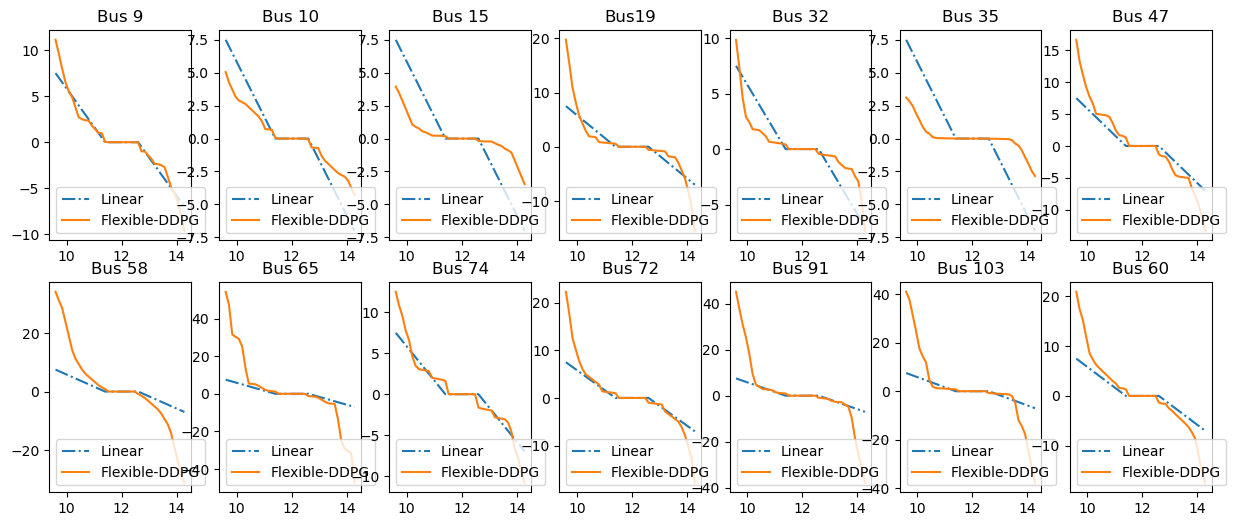

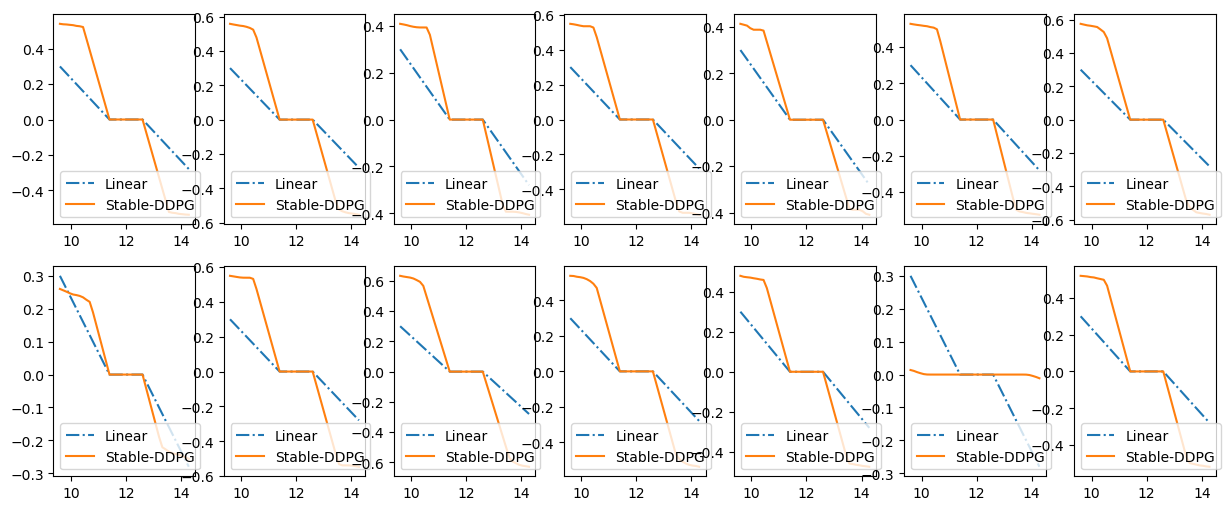

In [14]:
plot_policy(agent_policy_net, topology)
plot_safe_net(safe_agent_net)

### Flexible NN Contoller

In [15]:
### test our controller
voltage = []
q = []
cost = []
success_list = []
fail_list = []
entire_list = []
control_cost = []
reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(agent_num):
            action_agent = agent_policy_net[i](torch.cuda.FloatTensor(state[i].reshape(1,)).unsqueeze(0), topology)
            action_agent = action_agent.detach().cpu().numpy()[0]
            action.append(action_agent)

        action = last_action - np.asarray(action)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            success_list.append((episode,step))
            logger.success('episode {} stable at {} steps',success_list[-1][0], success_list[-1][1])
            break

        voltage.append(state)

        q.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    reward_list.append(episode_reward)
    control_cost.append(episode_control)

    if (not done) and (abnormal_stop == False):
        entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(success_list))
logger.info('total fail episode is {}', len(fail_list))
logger.info('number of finished at entire episode is {}', len(entire_list))

2025-02-26 16:51:42.647 | SUCCESS  | __main__:<module>:46 - episode 0 stable at 22 steps
2025-02-26 16:51:42.717 | SUCCESS  | __main__:<module>:46 - episode 1 stable at 0 steps
2025-02-26 16:51:44.972 | SUCCESS  | __main__:<module>:46 - episode 2 stable at 40 steps
2025-02-26 16:51:47.425 | SUCCESS  | __main__:<module>:46 - episode 3 stable at 43 steps
2025-02-26 16:51:48.241 | SUCCESS  | __main__:<module>:46 - episode 4 stable at 13 steps
2025-02-26 16:51:50.053 | SUCCESS  | __main__:<module>:46 - episode 5 stable at 32 steps
2025-02-26 16:51:50.535 | SUCCESS  | __main__:<module>:46 - episode 6 stable at 7 steps
2025-02-26 16:51:52.109 | SUCCESS  | __main__:<module>:46 - episode 7 stable at 27 steps
2025-02-26 16:51:55.151 | SUCCESS  | __main__:<module>:46 - episode 8 stable at 54 steps
2025-02-26 16:51:55.551 | SUCCESS  | __main__:<module>:46 - episode 9 stable at 6 steps
2025-02-26 16:51:56.594 | SUCCESS  | __main__:<module>:46 - episode 10 stable at 18 steps
2025-02-26 16:52:01.327

In [16]:
success_list = np.array(success_list)
print('average recovery step is:')
print(np.mean(success_list[:,1]))
print(np.std(success_list[:,1]))
print('average reactive power cost is:')
print(np.mean(control_cost))
print(np.std(control_cost))


average recovery step is:
15.061855670103093
12.621217966117259
average reactive power cost is:
465.78036208696466
1179.715199360617


In [14]:
### test our controller without topology change
voltage_ = []
q_ = []
cost_ = []
success_list_ = []
fail_list_ = []
entire_list_ = []
control_cost_ = []
reward_list_ = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = 1/env.topology_init
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(agent_num):
            action_agent = agent_policy_net[i](torch.cuda.FloatTensor(state[i].reshape(1,)).unsqueeze(0), topology)
            action_agent = action_agent.detach().cpu().numpy()[0]
            action.append(action_agent)

        action = last_action - np.asarray(action)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            fail_list_.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage_ violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            fail_list_.append((episode,step))
            abnormal_stop = True
            break
        if done:
            success_list_.append((episode,step))
            logger.success('stable at {}',success_list_[-1])
            break

        voltage_.append(state)

        q_.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost_.append(-reward)
        
        episode_control += LA.norm(action, 2)

    reward_list_.append(episode_reward)
    control_cost_.append(episode_control)

    if (not done) and (abnormal_stop == False):
        entire_list_.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(success_list_))
logger.info('total fail episode is {}', len(fail_list_))
logger.info('number of finished at entire episode is {}', len(entire_list_))

2023-09-14 11:19:15.697 | SUCCESS  | __main__:<module>:47 - stable at (0, 43)
2023-09-14 11:19:15.780 | SUCCESS  | __main__:<module>:47 - stable at (1, 0)
2023-09-14 11:19:19.929 | SUCCESS  | __main__:<module>:47 - stable at (2, 73)
2023-09-14 11:19:22.317 | SUCCESS  | __main__:<module>:47 - stable at (3, 44)
2023-09-14 11:19:23.367 | SUCCESS  | __main__:<module>:47 - stable at (4, 16)
2023-09-14 11:19:25.535 | SUCCESS  | __main__:<module>:47 - stable at (5, 36)
2023-09-14 11:19:26.016 | SUCCESS  | __main__:<module>:47 - stable at (6, 8)
2023-09-14 11:19:27.521 | SUCCESS  | __main__:<module>:47 - stable at (7, 26)
2023-09-14 11:19:28.455 | SUCCESS  | __main__:<module>:47 - stable at (8, 10)
2023-09-14 11:19:28.653 | SUCCESS  | __main__:<module>:47 - stable at (9, 2)
2023-09-14 11:19:29.295 | SUCCESS  | __main__:<module>:47 - stable at (10, 9)
2023-09-14 11:19:30.232 | SUCCESS  | __main__:<module>:47 - stable at (11, 13)
2023-09-14 11:19:30.996 | SUCCESS  | __main__:<module>:47 - stable

In [15]:
success_list_ = np.array(success_list_)
print('average recovery step is:')
print(np.mean(success_list_[:,1]))
print(np.std(success_list_[:,1]))
print('average reactive power cost is:')
print(np.mean(control_cost_))
print(np.std(control_cost_))

average recovery step is:
15.52
14.041709297660312
average reactive power cost is:
274.70653926175567
354.50663172793594


### baseline

In [20]:
### test the base line controller
voltage = []
q = []
cost = []
base_succ_list = []
base_fail_list = []
base_entire_list = []
base_control_cost = []
base_reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        state1 = np.asarray(state-env.vmax)
        state2 = np.asarray(env.vmin-state)
        d_v = (np.maximum(state1, 0)-np.maximum(state2, 0)).reshape((agent_num,1))
        
        action = (last_action - 30*d_v)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            base_fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            base_fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            base_succ_list.append((episode,step))
            logger.success('stable at {}',base_succ_list[-1])
            break

        voltage.append(state)

        q.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    base_control_cost.append(episode_control)
    base_reward_list.append(episode_reward)
    
    if (not done) and (abnormal_stop == False):
        base_entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(base_succ_list))
logger.info('total fail episode is {}', len(base_fail_list))
logger.info('number of finished at entire episode is {}', len(base_entire_list))

2023-09-14 11:32:49.882 | SUCCESS  | __main__:<module>:44 - stable at (0, 130)
2023-09-14 11:32:50.610 | SUCCESS  | __main__:<module>:44 - stable at (1, 41)
2023-09-14 11:32:53.720 | INFO     | __main__:<module>:64 - Episode 2 finish with entire step!
2023-09-14 11:32:56.657 | INFO     | __main__:<module>:64 - Episode 3 finish with entire step!
2023-09-14 11:32:58.078 | SUCCESS  | __main__:<module>:44 - stable at (4, 93)
2023-09-14 11:33:01.060 | INFO     | __main__:<module>:64 - Episode 5 finish with entire step!
2023-09-14 11:33:02.115 | SUCCESS  | __main__:<module>:44 - stable at (6, 67)
2023-09-14 11:33:04.990 | SUCCESS  | __main__:<module>:44 - stable at (7, 187)
2023-09-14 11:33:06.756 | SUCCESS  | __main__:<module>:44 - stable at (8, 114)
2023-09-14 11:33:08.745 | SUCCESS  | __main__:<module>:44 - stable at (9, 111)
2023-09-14 11:33:11.427 | SUCCESS  | __main__:<module>:44 - stable at (10, 152)
2023-09-14 11:33:13.932 | SUCCESS  | __main__:<module>:44 - stable at (11, 154)
2023-

In [21]:
base_succ_list = np.array(base_succ_list)
print('average recovery step is:')
print(np.mean(base_succ_list[:,1]))
print(np.std(base_succ_list[:,1]))
print('average reactive power cost is:')
print(np.mean(base_control_cost))
print(np.std(base_control_cost))


average recovery step is:
104.93548387096774
39.20632120736821
average reactive power cost is:
1867.4750974197266
1677.1705608820203


### Safe DDPG

In [18]:
### test the safe policy net
safe_voltage = []
safe_q = []
safe_cost = []
safe_succ_list = []
safe_fail_list = []
safe_entire_list = []
safe_contorl_cost = []
safe_reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(agent_num):
            action_agent = safe_agent_net[i].get_action(torch.cuda.FloatTensor([state[i]]).float().reshape(1,1))
            action.append(action_agent)
        
        action = last_action - 10*np.asarray(action).reshape((agent_num, 1))
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            safe_succ_list.append((episode,step))
            logger.success('stable at {}',safe_succ_list[-1])
            break
        safe_voltage.append(state)

        safe_q.append(action)

        state = next_state
        
        episode_reward += reward
        
        safe_cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    safe_contorl_cost.append(episode_control)
    safe_reward_list.append(episode_reward)

    if (not done) and (abnormal_stop == False):
        safe_entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(safe_succ_list))
logger.info('total fail episode is {}', len(safe_fail_list))
logger.info('number of finished at entire episode is {}', len(safe_entire_list))


2023-09-14 11:25:24.677 | SUCCESS  | __main__:<module>:45 - stable at (0, 57)
2023-09-14 11:25:25.351 | SUCCESS  | __main__:<module>:45 - stable at (1, 16)
2023-09-14 11:25:29.197 | SUCCESS  | __main__:<module>:45 - stable at (2, 99)
2023-09-14 11:25:33.696 | SUCCESS  | __main__:<module>:45 - stable at (3, 118)
2023-09-14 11:25:35.282 | SUCCESS  | __main__:<module>:45 - stable at (4, 39)
2023-09-14 11:25:39.439 | SUCCESS  | __main__:<module>:45 - stable at (5, 107)
2023-09-14 11:25:40.517 | SUCCESS  | __main__:<module>:45 - stable at (6, 26)
2023-09-14 11:25:43.633 | SUCCESS  | __main__:<module>:45 - stable at (7, 80)
2023-09-14 11:25:45.472 | SUCCESS  | __main__:<module>:45 - stable at (8, 47)
2023-09-14 11:25:53.210 | INFO     | __main__:<module>:64 - Episode 9 finish with entire step!
2023-09-14 11:26:01.224 | INFO     | __main__:<module>:64 - Episode 10 finish with entire step!
2023-09-14 11:26:04.780 | SUCCESS  | __main__:<module>:45 - stable at (11, 88)
2023-09-14 11:26:12.508 | 

In [27]:
safe_succ_list = np.array(safe_succ_list)
print('average recovery step is:')
print(np.mean(safe_succ_list[:,1]))
print(np.std(safe_succ_list[:,1]))
print('average reactive power cost is:')
print(np.mean(safe_contorl_cost))
print(np.std(safe_contorl_cost))

average recovery step is:
49.24731182795699
24.1583734738654
average reactive power cost is:
990.233525479899
982.4322344902253
